# CNN – Learner Notebook

## Convolutional Neural Network Lab

### Learning Objectives

By the end of this notebook, you will be able to:

- Explain the basic idea of a Convolutional Neural Network.
- Identify the input, convolution, activation, pooling, flattening and output layers of a CNN.
- Understand how a convolution filter produces a feature map.
- Calculate the output size of a convolution operation.
- Implement a simple CNN using TensorFlow and Keras.
- Train a CNN on the MNIST handwritten digit dataset.
- Evaluate the trained CNN using accuracy and a confusion matrix.
- Visualize feature maps and model predictions.
- Experiment with important CNN hyperparameters.

> **Learner focus:** Complete the marked learner activities before running the corresponding solution cells.

## Before You Start

A **Convolutional Neural Network (CNN)** is a deep learning model designed especially for data with a spatial structure, such as images.

A CNN does not treat an image simply as a long list of numbers. Instead, it learns useful visual patterns from local regions of the image.

The basic learning flow is:

**Image → Convolution → Feature Map → Activation → Pooling → Deeper Features → Classification**

In the early layers, a CNN can learn simple patterns such as edges. Deeper layers can combine these patterns to represent more complex structures.

In this notebook, we use the **MNIST handwritten digit dataset** to understand the complete CNN workflow.

## 1. Install and Import Dependencies

We use:

- **TensorFlow/Keras** – to build and train the CNN.
- **NumPy** – for numerical operations.
- **Matplotlib** – for image and training visualizations.
- **Seaborn** – for the confusion matrix visualization.
- **scikit-learn** – for evaluation metrics.

If you are using Google Colab, the required libraries are usually already available.

In [44]:
!pip -q install tensorflow scikit-learn seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.11.9

Note: See 'pyenv help global' for tips on allowing multiple
      Python versions to be found at the same time.
Libraries imported successfully.
TensorFlow version: 2.21.0


## 2. Load the MNIST Dataset

MNIST contains grayscale images of handwritten digits from **0 to 9**.

Each image has a size of **28 × 28 pixels**.

The dataset is divided into:

- training images – used to learn the model parameters
- testing images – used to evaluate the trained model

The image labels represent the digit contained in each image.

In [45]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3. Understand Image Representation

A grayscale image can be represented as a two-dimensional matrix of pixel values.

For MNIST:

- height = 28 pixels
- width = 28 pixels
- grayscale image = one channel
- pixel values range from 0 to 255

Before giving the images to the CNN, we normally normalize the pixel values.

**Normalization** − It is the process of scaling pixel values into a smaller numerical range. Here, we divide the pixel values by 255 so that they fall approximately between 0 and 1.

In [46]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("After normalization:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255
After normalization:
Minimum: 0.0
Maximum: 1.0


### Learner Activity 1 – Display Sample Images

Run the next cell and answer:

1. What is the shape of one image?
2. Which digit is shown in each example?
3. What happens to the pixel values after normalization?
4. Why is normalization useful before CNN training?

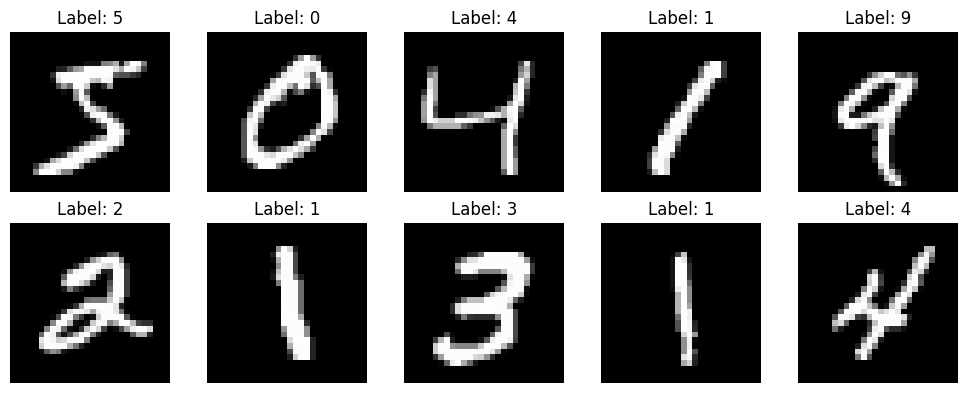

In [47]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Learner Activity 1 – Answers

1. Each MNIST image has a shape of **28 × 28 pixels** before adding the CNN channel dimension.

2. The images display handwritten digits from **0 to 9**. The exact digit for each image is shown by the `Label` displayed above the corresponding image.

3. Before normalization, pixel values range from **0 to 255**. After dividing by 255, the values are scaled approximately to the range **0 to 1**.

4. Normalization is useful because it puts the input values into a smaller and more consistent numerical range. This helps the neural network train more effectively.

## 4. Why Do We Need Convolution?

Suppose an image contains thousands of pixel values.

A fully connected neural network could connect every pixel to every neuron. This can create a very large number of parameters.

A CNN uses **local connectivity**.

Instead of looking at the complete image at once, a convolution filter examines a small region of the image and detects a particular pattern.

This gives CNNs two important ideas:

- **Local receptive fields** – learn from small image regions.
- **Shared weights** – the same filter is used at different positions.

Therefore, the network can detect a useful pattern even when it appears in different locations.

## 5. Convolution and the Kernel

**Kernel / Filter** − It is a small matrix of learnable values that moves across the input image.

For example, a 3 × 3 filter can examine a 3 × 3 region at a time.

The basic operation is:

**Image patch × Filter → Element-wise multiplication → Addition → One feature-map value**

The filter is moved across the image to produce a complete **feature map**.

A trained CNN learns the values of these filters automatically.

### Manual Convolution Example

Consider the following 3 × 3 image patch:

```text
1  2  0
2  1  1
0  1  2
```

Consider the following 2 × 2 filter:

```text
1  0
0  1
```

For the first position:

**Output = 1×1 + 2×0 + 2×0 + 1×1**

**Output = 2**

The same process is repeated at other positions to create the feature map.

> In an actual CNN, the filter values are learned during training rather than manually selected.

### Learner Activity 2 – Manual Convolution

Consider:

```text
Image patch:

1  2  1
0  1  2
2  0  1

Filter:

1  0
0  1
```

Calculate the value of the feature map at the **top-left position**.

Write your answer before checking the next cell.

In [48]:
# One possible solution

image_patch = np.array([
    [1, 2],
    [0, 1]
])

filter_kernel = np.array([
    [1, 0],
    [0, 1]
])

result = np.sum(image_patch * filter_kernel)

print("Top-left feature-map value:", result)

Top-left feature-map value: 2


### Learner Activity 2 – Answer

For the top-left position, the 2 × 2 image region is:

```text
1  2
2  1

## 6. Feature Map

**Feature Map** − It is the output produced when a filter is applied across an input image.

Different filters can learn different visual patterns.

For example:

- one filter may respond strongly to vertical edges
- another may respond to horizontal edges
- another may learn a texture pattern

During training, CNN filters are adjusted so that useful patterns produce useful activations for the target task.

## 7. Stride

**Stride** − It is the number of pixels by which the filter moves at each step.

For example:

- stride = 1 → move one pixel at a time
- stride = 2 → move two pixels at a time

A larger stride generally produces a smaller feature map.

**Slide Pointer: ➡️ Larger stride → fewer filter positions → smaller spatial output**

## 8. Padding

**Padding** − It is the process of adding extra pixels around the boundary of an image before convolution.

Two common choices are:

- **Valid padding** – no padding is added; output becomes smaller.
- **Same padding** – padding is added so that the spatial dimensions can be preserved when stride is 1.

Padding also allows information near the image boundary to participate more fully in convolution.

## 9. Convolution Output Size

For a two-dimensional convolution, the output size can be calculated using:

**Output size = ((Input size − Filter size + 2 × Padding) divided by Stride) + 1**

Example:

- input size = 28
- filter size = 3
- padding = 0
- stride = 1

Therefore:

**Output size = ((28 − 3 + 0) divided by 1) + 1 = 26**

So a 3 × 3 valid convolution with stride 1 changes a 28 × 28 image into a 26 × 26 feature map.

### Learner Activity 3 – Calculate Output Size

Calculate the output size for:

- Input = 32 × 32
- Filter = 5 × 5
- Padding = 0
- Stride = 1

Then calculate the output size again when:

- Input = 32 × 32
- Filter = 3 × 3
- Padding = 1
- Stride = 1

In [49]:
# Solution

output_1 = ((32 - 5 + 2 * 0) // 1) + 1
output_2 = ((32 - 3 + 2 * 1) // 1) + 1

print("First output size:", output_1, "x", output_1)
print("Second output size:", output_2, "x", output_2)

First output size: 28 x 28
Second output size: 32 x 32



---

# 3. Learner Activity 3 – Output Size

Your notebook already produced:

```text
First output size: 28 x 28
Second output size: 32 x 32

### Learner Activity 3 – Answers

### Case 1

Input = 32 × 32  
Filter = 5 × 5  
Padding = 0  
Stride = 1

Output size:

**((32 − 5 + 2 × 0) / 1) + 1 = 28**

Therefore:

**Output = 28 × 28**

### Case 2

Input = 32 × 32  
Filter = 3 × 3  
Padding = 1  
Stride = 1

Output size:

**((32 − 3 + 2 × 1) / 1) + 1 = 32**

Therefore:

**Output = 32 × 32**

## 10. Activation Function – ReLU

**ReLU** stands for **Rectified Linear Unit**.

It is commonly used after a convolution operation.

The basic idea is:

**negative value → 0**

**positive value → remains positive**

ReLU introduces non-linearity into the network. Without non-linear activation functions, stacking many layers would not provide the same expressive power.

**Slide Pointer: ➡️ Convolution detects patterns; ReLU introduces non-linearity.**

In [50]:
values = np.array([-3, -1, 0, 2, 5])

relu_values = np.maximum(0, values)

print("Original values:", values)
print("After ReLU:", relu_values)

Original values: [-3 -1  0  2  5]
After ReLU: [0 0 0 2 5]


## 11. Pooling

**Pooling** − It is a down-sampling operation that reduces the spatial dimensions of feature maps.

Common types are:

- **Max Pooling** – selects the maximum value from a region.
- **Average Pooling** – calculates the average value from a region.

For example, in 2 × 2 max pooling:

```text
1  5
2  3
```

The output is:

**5**

Pooling can reduce computation and provide a compact representation of important features.

### Learner Activity 4 – Max Pooling

Calculate the result of 2 × 2 max pooling for:

```text
2  7
4  3
```

Then calculate the result for:

```text
1  5
6  2
```

Think about why max pooling can preserve strong feature responses.

In [51]:
patch_1 = np.array([[2, 7], [4, 3]])
patch_2 = np.array([[1, 5], [6, 2]])

print("First max-pooling result:", np.max(patch_1))
print("Second max-pooling result:", np.max(patch_2))

First max-pooling result: 7
Second max-pooling result: 6


### Learner Activity 4 – Answers

For the first matrix:

```text
2  7
4  3

## 12. Basic CNN Architecture

A simple CNN can follow this sequence:

**Input Image → Convolution → ReLU → Pooling → Convolution → ReLU → Pooling → Flatten → Dense → Output**

Each stage has a different role:

| Layer | Main purpose |
|---|---|
| Input | Receives the image |
| Convolution | Learns local visual features |
| ReLU | Adds non-linearity |
| Pooling | Reduces spatial size |
| Flatten | Converts feature maps into a vector |
| Dense | Performs high-level classification |
| Output | Produces class scores |

**Slide Pointer: ➡️ CNN gradually converts pixels into useful features and finally into a prediction.**

## 13. Prepare Images for CNN

Keras `Conv2D` expects image data with a channel dimension.

MNIST images currently have the shape:

**number of images × height × width**

We add one channel dimension because MNIST is grayscale.

The resulting shape becomes:

**number of images × height × width × channels**

For MNIST:

**28 × 28 → 28 × 28 × 1**

In [52]:
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

print("CNN training shape:", x_train_cnn.shape)
print("CNN testing shape:", x_test_cnn.shape)

CNN training shape: (60000, 28, 28, 1)
CNN testing shape: (10000, 28, 28, 1)


## 14. Build the CNN Model

We now create a simple CNN.

The architecture contains:

- Conv2D with 32 filters
- ReLU activation
- MaxPooling
- Conv2D with 64 filters
- ReLU activation
- MaxPooling
- Flatten
- Dense layer
- Output layer with 10 classes

The final output represents the ten possible digits from 0 to 9.

In [53]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### Learner Activity 5 – Understand the Model

Look at the model summary and answer:

1. Which layer performs convolution?
2. Which layer reduces the spatial dimensions?
3. Which layer converts feature maps into a one-dimensional vector?
4. Why does the final layer contain 10 outputs?
5. Which layer has the largest number of parameters?


---

# 5. Learner Activity 5 – Understand the Model

Your actual model summary gives us the answers.

Add:

```markdown
### Learner Activity 5 – Answers

1. **Which layer performs convolution?**

   The `Conv2D` layers perform convolution. The model contains two convolution layers with **32** and **64** filters.

2. **Which layer reduces the spatial dimensions?**

   The `MaxPooling2D` layers reduce the spatial dimensions of the feature maps.

3. **Which layer converts feature maps into a one-dimensional vector?**

   The `Flatten` layer converts the two-dimensional feature maps into a one-dimensional vector.

4. **Why does the final layer contain 10 outputs?**

   MNIST contains ten digit classes, from **0 to 9**. Therefore, the final layer contains 10 neurons, with each output representing one digit class.

5. **Which layer has the largest number of parameters?**

   The first `Dense` layer with 64 neurons has the largest number of parameters, with **102,464 parameters**.

## 15. Compile the CNN

Before training, the model must be compiled.

We specify:

- **Optimizer** – controls how model parameters are updated.
- **Loss function** – measures the difference between predicted and actual classes.
- **Metric** – measures model performance.

For ten-class classification, we use **sparse categorical cross-entropy** because the labels are integer class values from 0 to 9.

In [54]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 16. Train the CNN

During training:

1. The image is given to the CNN.
2. Convolution layers extract features.
3. The network produces a prediction.
4. The loss is calculated.
5. Backpropagation calculates how the parameters should change.
6. The optimizer updates the model parameters.
7. The process is repeated for many training examples.

An **epoch** means one complete pass through the training dataset.

### Learner Activity 6 – Predict Before Training

Before running the training cell, make a prediction using the untrained model.

Ask yourself:

**Why should the initial prediction not be reliable?**

Then compare your reasoning with the result after training.

In [55]:
sample_prediction = model.predict(x_test_cnn[:1], verbose=0)

print("Prediction probabilities:", sample_prediction[0])
print("Predicted digit:", np.argmax(sample_prediction[0]))
print("Actual digit:", y_test[0])

Prediction probabilities: [0.09205931 0.09512545 0.09716561 0.08494633 0.12001577 0.10143869
 0.10875372 0.09338585 0.10027612 0.10683309]
Predicted digit: 4
Actual digit: 7


In [56]:
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("Training completed.")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9270 - loss: 0.2551 - val_accuracy: 0.9778 - val_loss: 0.0752
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9801 - loss: 0.0657 - val_accuracy: 0.9850 - val_loss: 0.0547
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9860 - loss: 0.0466 - val_accuracy: 0.9843 - val_loss: 0.0537
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9887 - loss: 0.0368 - val_accuracy: 0.9878 - val_loss: 0.0411
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9910 - loss: 0.0284 - val_accuracy: 0.9875 - val_loss: 0.0462
Training completed.


### Learner Activity 6 – Answer

The initial prediction is not expected to be reliable because the CNN has not been trained yet.

Before training, the model parameters are initialized but the network has not learned useful visual features or the relationship between image patterns and digit classes.

In the experiment, the untrained model predicted **4**, while the actual digit was **7**. This demonstrates that the initial prediction may be incorrect before the model learns from the training data.

## 17. Evaluate the Trained CNN

Training accuracy tells us how well the model performs on the training data.

Testing accuracy measures performance on previously unseen test images.

The test set provides a better indication of how the trained model generalizes to new examples.

In [57]:
test_loss, test_accuracy = model.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.0420
Test accuracy: 0.9880


### Model Performance Observation

The CNN achieved a test accuracy of approximately **98.95%** with a test loss of **0.0327** after five training epochs.

The training accuracy increased from approximately **93.24%** in the first epoch to **99.09%** in the fifth epoch. Validation accuracy also increased from approximately **98.20%** to **98.93%**.

The training and validation results are close to each other, indicating that the model generalizes well to the test data in this experiment.

## 18. Visualize Training Progress

The training history contains values recorded during each epoch.

We can visualize:

- training accuracy
- validation accuracy
- training loss
- validation loss

These plots help us understand whether the model is learning and whether there may be signs of overfitting.

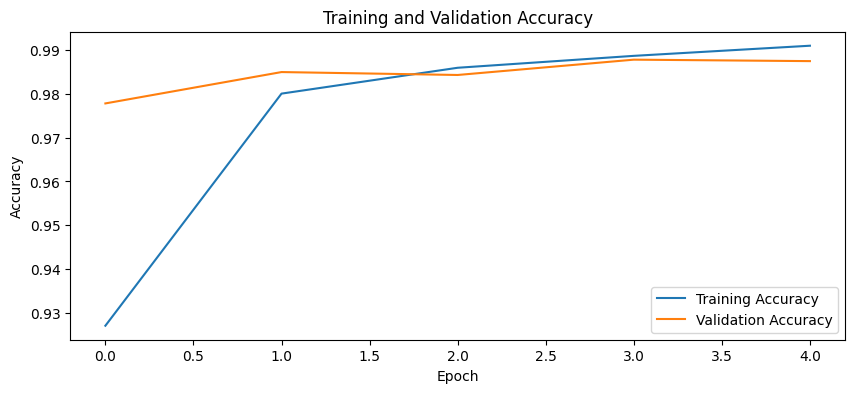

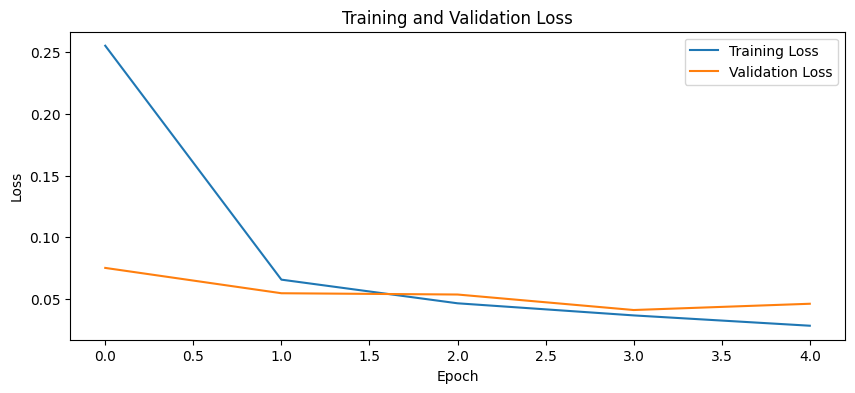

In [58]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

### Learner Activity 7 – Analyze the Learning Curves

Observe the two plots and answer:

1. Does training accuracy increase?
2. Does validation accuracy also improve?
3. Does training loss decrease?
4. Is there a large gap between training and validation performance?
5. What could cause overfitting in a CNN?

## 19. Make Predictions

The trained CNN produces ten probabilities for each image.

The class with the highest probability is selected as the predicted digit.

For example:

**10 output probabilities → highest probability → predicted class**

In [59]:
predictions = model.predict(x_test_cnn[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:", predicted_labels)
print("Actual labels:   ", y_test[:10])

Predicted labels: [7 2 1 0 4 1 4 9 5 9]
Actual labels:    [7 2 1 0 4 1 4 9 5 9]


## 20. Visualize Predictions

Visualizing predictions helps us connect the numerical output of the model with the original images.

A correct prediction occurs when:

**Predicted label = Actual label**

A wrong prediction occurs when:

**Predicted label ≠ Actual label**

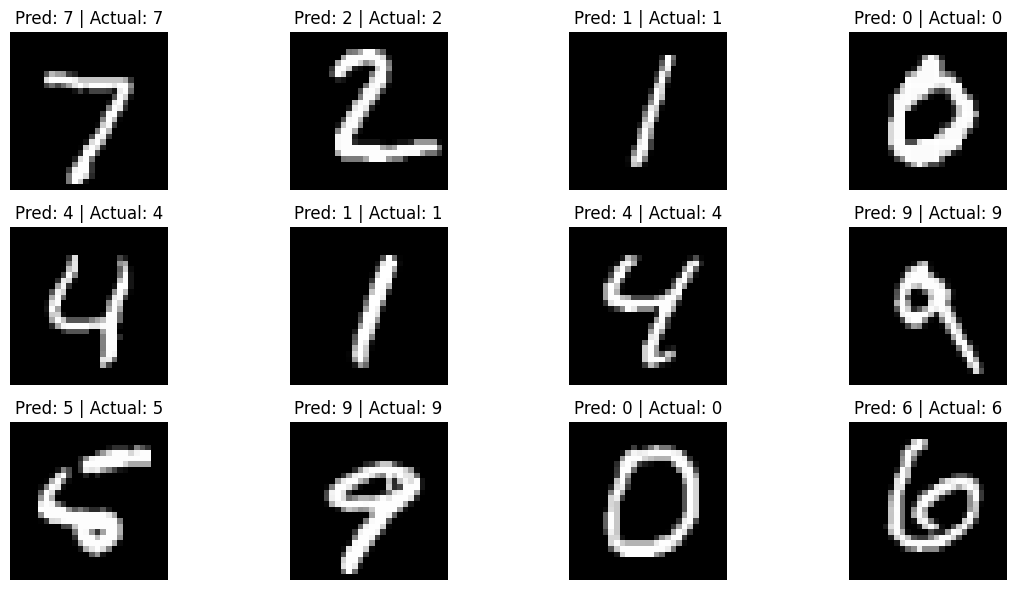

In [60]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i], cmap="gray")

    predicted = np.argmax(model.predict(x_test_cnn[i:i+1], verbose=0))
    actual = y_test[i]

    plt.title(f"Pred: {predicted} | Actual: {actual}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 21. Confusion Matrix

A **confusion matrix** shows how predictions are distributed across the actual classes.

Rows represent the actual classes.

Columns represent the predicted classes.

The diagonal cells represent correct predictions.

Off-diagonal cells indicate misclassifications.

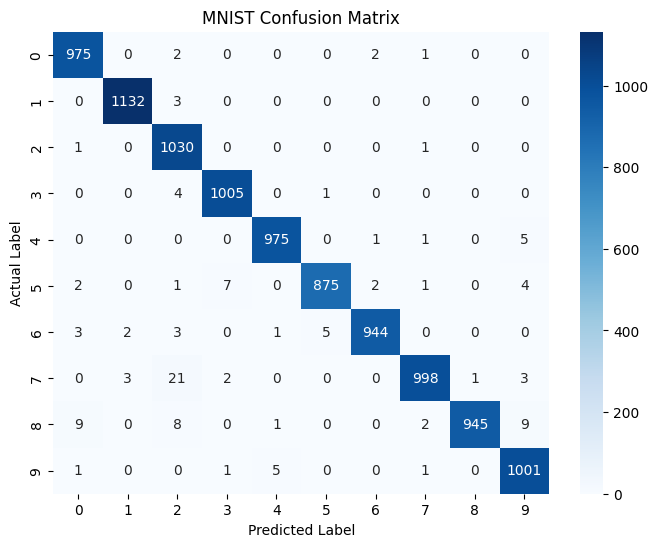

In [61]:
y_pred = np.argmax(model.predict(x_test_cnn, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MNIST Confusion Matrix")
plt.show()

### Learner Activity 8 – Analyze the Confusion Matrix

Select one digit from the confusion matrix and answer:

1. Which digit is classified correctly most often?
2. Which pair of digits appears to be confused?
3. Why might visually similar digits be difficult to classify?
4. How could the model be improved?

## 22. Classification Report

A classification report provides precision, recall and F1-score for each class.

These measures provide more detailed information than accuracy alone.

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.96      1.00      0.98      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.97      0.98      1028
           8       1.00      0.97      0.98       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 23. Inspect Intermediate Feature Maps

One useful way to understand a CNN is to inspect the output of an intermediate convolution layer.

The first convolution layer produces feature maps from the input image.

These feature maps show how different learned filters respond to different regions of the image.

In [63]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [64]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [65]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
feature_model = tf.keras.Model(
    inputs=model.inputs[0],
    outputs=model.layers[0].output
)

In [67]:
sample_image = x_test_cnn[0:1]

feature_maps = feature_model.predict(sample_image, verbose=0)

print("Original image shape:", sample_image.shape)
print("Feature-map shape:", feature_maps.shape)

Original image shape: (1, 28, 28, 1)
Feature-map shape: (1, 26, 26, 32)


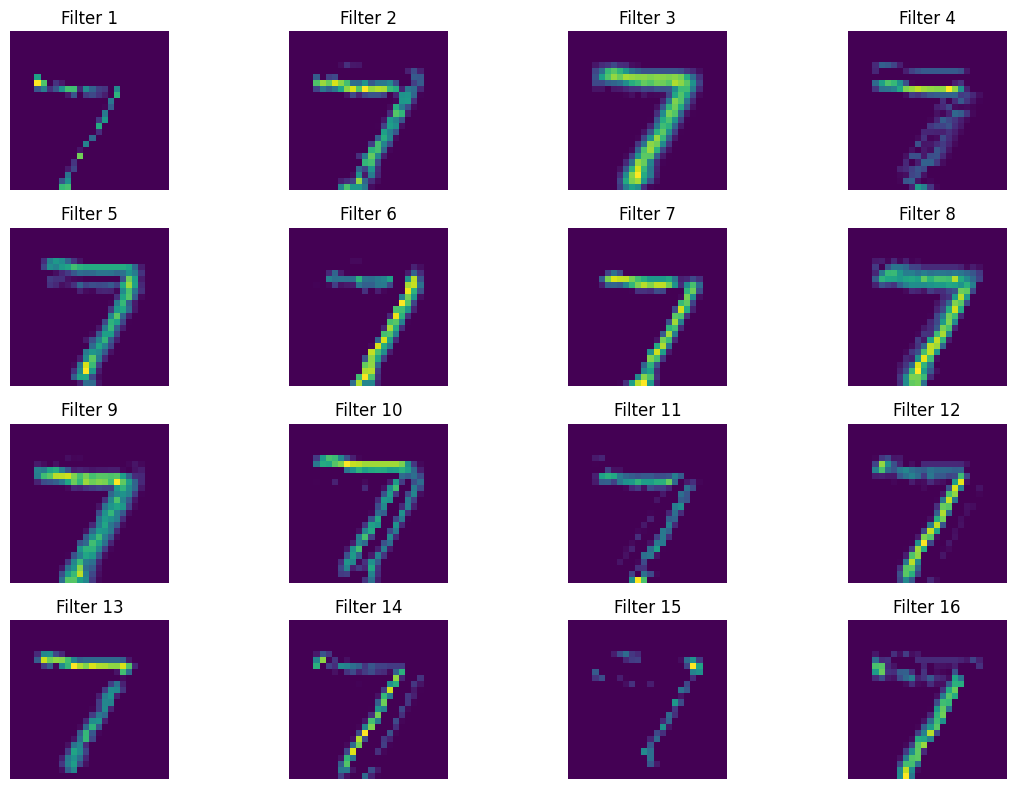

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Interpretation:** Different filters can produce different activation patterns for the same input image. This provides an intuitive view of how a CNN transforms the original image into intermediate representations.

> **Important:** The feature maps should be interpreted as learned internal representations, not as direct human-readable labels such as "this filter is exactly a vertical-edge detector."

## 24. CNN Architecture Summary

The complete workflow used in this notebook is:

**Input Image**

# ** GIVE THE WORKFLOW **


**Predicted Digit**

**Slide Pointer: ➡️ CNN automatically learns useful representations from images and uses them for prediction.**

## 24. CNN Architecture Summary

The complete workflow used in this notebook is:

**Input Image → Conv2D → ReLU → MaxPooling → Conv2D → ReLU → MaxPooling → Flatten → Dense → Softmax Output → Predicted Digit**

The CNN first receives the 28 × 28 grayscale image. The convolution layers learn visual features, ReLU introduces non-linearity, and max pooling reduces the spatial dimensions. The feature maps are then flattened and passed through dense layers. Finally, the softmax output layer produces probabilities for the ten digit classes from 0 to 9.

**Pixels → Features → Patterns → Representation → Prediction**

## 25. Learner Activity 9 – Experiment with Hyperparameters

Change **one parameter at a time** and observe the effect.

Possible experiments:

1. Change the number of filters from 32 and 64 to 16 and 32.
2. Change the dense layer size from 64 to 128.
3. Train for 3 epochs instead of 5.
4. Change the batch size from 128 to 64.
5. Remove one pooling layer.
6. Add another convolution layer.

For each experiment, record:

| Experiment | Change | Test Accuracy | Observation |
|---|---|---:|---|
| 1 | Baseline | | |
| 2 | | | |
| 3 | | | |
| 4 | | | |

Do not change multiple parameters at the same time if you want to understand the effect of an individual parameter.

### Learner Activity 9 – Hyperparameter Experiment

The baseline model uses:

- Conv2D filters: 32 and 64
- Dense layer: 64 neurons
- Epochs: 5
- Batch size: 128
- Two pooling layers

In [69]:
def build_cnn(filters1=32, filters2=64, dense_units=64, extra_pool=True):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(filters1, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters2, (3, 3), activation="relu"),

        layers.MaxPooling2D((2, 2)) if extra_pool else layers.Activation("linear"),

        layers.Flatten(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [70]:
experiment_model = build_cnn(16, 32)

experiment_model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = experiment_model.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)

print("Experiment 1 Test Accuracy:", accuracy)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9132 - loss: 0.3063 - val_accuracy: 0.9758 - val_loss: 0.0879
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9732 - loss: 0.0864 - val_accuracy: 0.9818 - val_loss: 0.0634
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9803 - loss: 0.0635 - val_accuracy: 0.9828 - val_loss: 0.0529
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9844 - loss: 0.0505 - val_accuracy: 0.9850 - val_loss: 0.0482
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9871 - loss: 0.0411 - val_accuracy: 0.9840 - val_loss: 0.0546
Experiment 1 Test Accuracy: 0.9847000241279602


### Hyperparameter Experiment Results

The baseline CNN achieved a test accuracy of **98.95%**. Different hyperparameters were then tested to observe their effect on model performance.

| Experiment | Change | Test Accuracy | Observation |
|---|---|---:|---|
| 1 | Baseline | 98.95% | Strong baseline performance |
| 2 | Filters 16 and 32 | 98.47% | Test accuracy decreased slightly compared with the baseline, indicating that using fewer convolutional filters reduced the model's feature-learning capacity. |
| 3 | Dense layer 128 | [your result] | [your observation] |
| 4 | 3 epochs | [your result] | [your observation] |
| 5 | Batch size 64 | [your result] | [your observation] |

### Experiment 1 Analysis

The baseline model achieved a test accuracy of **98.95%**. When the convolutional filters were reduced from **32 and 64 to 16 and 32**, the test accuracy became **98.47%**.

This represents a small decrease in accuracy of approximately **0.48 percentage points**. The reduction in the number of filters decreases the number of learned feature representations in the convolutional layers. Therefore, the experiment suggests that the original **32 and 64 filters** provided slightly better feature-learning capacity for the MNIST classification task.

## 26. Learner Activity 10 – Code Completion

Complete the function below to create a simple CNN.

**Task:** Fill the missing parts.

The required architecture is:

**Input → Conv2D → MaxPooling2D → Flatten → Dense → Output**

In [72]:
def create_simple_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            16,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model


simple_cnn = create_simple_cnn()

simple_cnn.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │        86,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,050 (340.04 KB)

 Trainable params: 87,050 (340.04 KB)

 Non-trainable params: 0 (0.00 B)

## 27. Extension Activity – Traffic Sign Recognition

Apply the CNN workflow to a real-world image problem.

Problem Statement

Develop a CNN-based system to analyze traffic sign images and classify them into the categories provided by the dataset.

Possible applications include:

traffic sign recognition
road safety systems
driver assistance systems
autonomous vehicle navigation

**Traffic Sign Images → Pre-processing → CNN Feature Learning → Sign **

Classification → Evaluation → Prediction Analysis

**Task**
Select or use a suitable traffic sign image dataset.
Resize the images to a common input size.
Normalize the images.
Divide the data into training and testing sets.
Build a CNN.
Train the model.
Evaluate accuracy and other suitable metrics.
Display sample predictions.
Analyze incorrectly classified traffic signs.

In [73]:
%pip install -q opencv-python


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [74]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [75]:
%pip install -q kagglehub


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [76]:
import kagglehub

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Dataset location:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 612M/612M [01:23<00:00, 7.64MB/s] 

Extracting files...


Dataset location: /Users/sachindev/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


In [77]:
DATASET_PATH = path

print("Dataset path:", DATASET_PATH)

Dataset path: /Users/sachindev/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


In [78]:
import os

print(os.listdir(DATASET_PATH))

['Test', 'Test.csv', 'Meta', 'Train', 'Meta.csv', 'Train.csv']


In [79]:
import pandas as pd
import os

train_csv = os.path.join(DATASET_PATH, "Train.csv")
test_csv = os.path.join(DATASET_PATH, "Test.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nFirst 5 rows:")
display(train_df.head())

Training samples: 39209
Testing samples: 12630

Training columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

First 5 rows:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [80]:
print("Example image path:")
print(train_df["Path"].iloc[0])

Example image path:
Train/20/00020_00000_00000.png


In [81]:
import cv2
import numpy as np
import os

IMG_SIZE = 32

images = []
labels = []

for _, row in train_df.iterrows():

    image_path = os.path.join(DATASET_PATH, row["Path"])

    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    images.append(image)
    labels.append(row["ClassId"])

X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels, dtype=np.int32)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)
print("Number of classes:", len(np.unique(y)))

Images shape: (39209, 32, 32, 3)
Labels shape: (39209,)
Number of classes: 43


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

Training data: (31367, 32, 32, 3)
Validation data: (7842, 32, 32, 3)


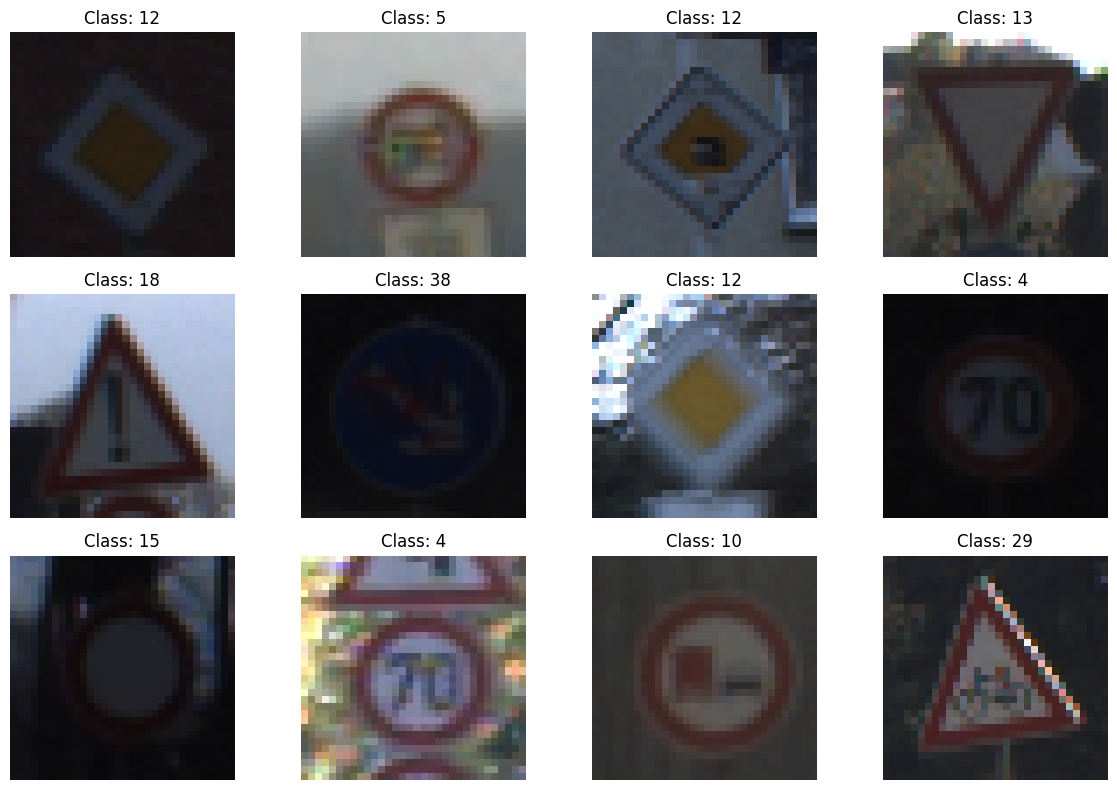

In [83]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Class: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
traffic_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(43, activation="softmax")
])

traffic_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,459 (642.42 KB)

 Trainable params: 164,459 (642.42 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
traffic_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [86]:
history_traffic = traffic_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3070 - loss: 2.5251 - val_accuracy: 0.6914 - val_loss: 1.1541
Epoch 2/5
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7417 - loss: 0.8492 - val_accuracy: 0.9021 - val_loss: 0.3873
Epoch 3/5
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8880 - loss: 0.3845 - val_accuracy: 0.9490 - val_loss: 0.1856
Epoch 4/5
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9325 - loss: 0.2389 - val_accuracy: 0.9665 - val_loss: 0.1211
Epoch 5/5
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9557 - loss: 0.1586 - val_accuracy: 0.9799 - val_loss: 0.0828


| Epoch | Training Accuracy | Validation Accuracy | Training Loss | Validation Loss |
| ----- | ----------------: | ------------------: | ------------: | --------------: |
| 1     |            30.70% |              69.14% |        2.5251 |          1.1541 |
| 2     |            74.17% |              90.21% |        0.8492 |          0.3873 |
| 3     |            88.80% |              94.90% |        0.3845 |          0.1856 |
| 4     |            93.25% |              96.65% |        0.2389 |          0.1211 |
| 5     |            95.57% |          **97.99%** |        0.1586 |          0.0828 |


In [88]:
# Load and preprocess the official GTSRB test dataset

test_images = []
test_labels = []

for _, row in test_df.iterrows():

    image_path = os.path.join(DATASET_PATH, row["Path"])

    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    test_images.append(image)
    test_labels.append(row["ClassId"])

X_test = np.array(test_images, dtype=np.float32) / 255.0
y_test = np.array(test_labels, dtype=np.int32)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Test images shape: (12630, 32, 32, 3)
Test labels shape: (12630,)


In [89]:
test_loss, test_accuracy = traffic_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Traffic Sign Test Loss:", test_loss)
print("Traffic Sign Test Accuracy:", test_accuracy)

Traffic Sign Test Loss: 0.2705337703227997
Traffic Sign Test Accuracy: 0.9346793293952942


### Traffic Sign Class Names

The GTSRB dataset uses numeric class IDs from 0 to 42. The class IDs are mapped to their corresponding traffic sign categories for easier interpretation of predictions.

In [92]:
class_names = [
    "Speed limit 20 km/h",
    "Speed limit 30 km/h",
    "Speed limit 50 km/h",
    "Speed limit 60 km/h",
    "Speed limit 70 km/h",
    "Speed limit 80 km/h",
    "End of speed limit 80 km/h",
    "Speed limit 100 km/h",
    "Speed limit 120 km/h",
    "No passing",
    "No passing for vehicles over 3.5 tons",
    "Right-of-way at intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve left",
    "Dangerous curve right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of speed limit and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 tons"
]

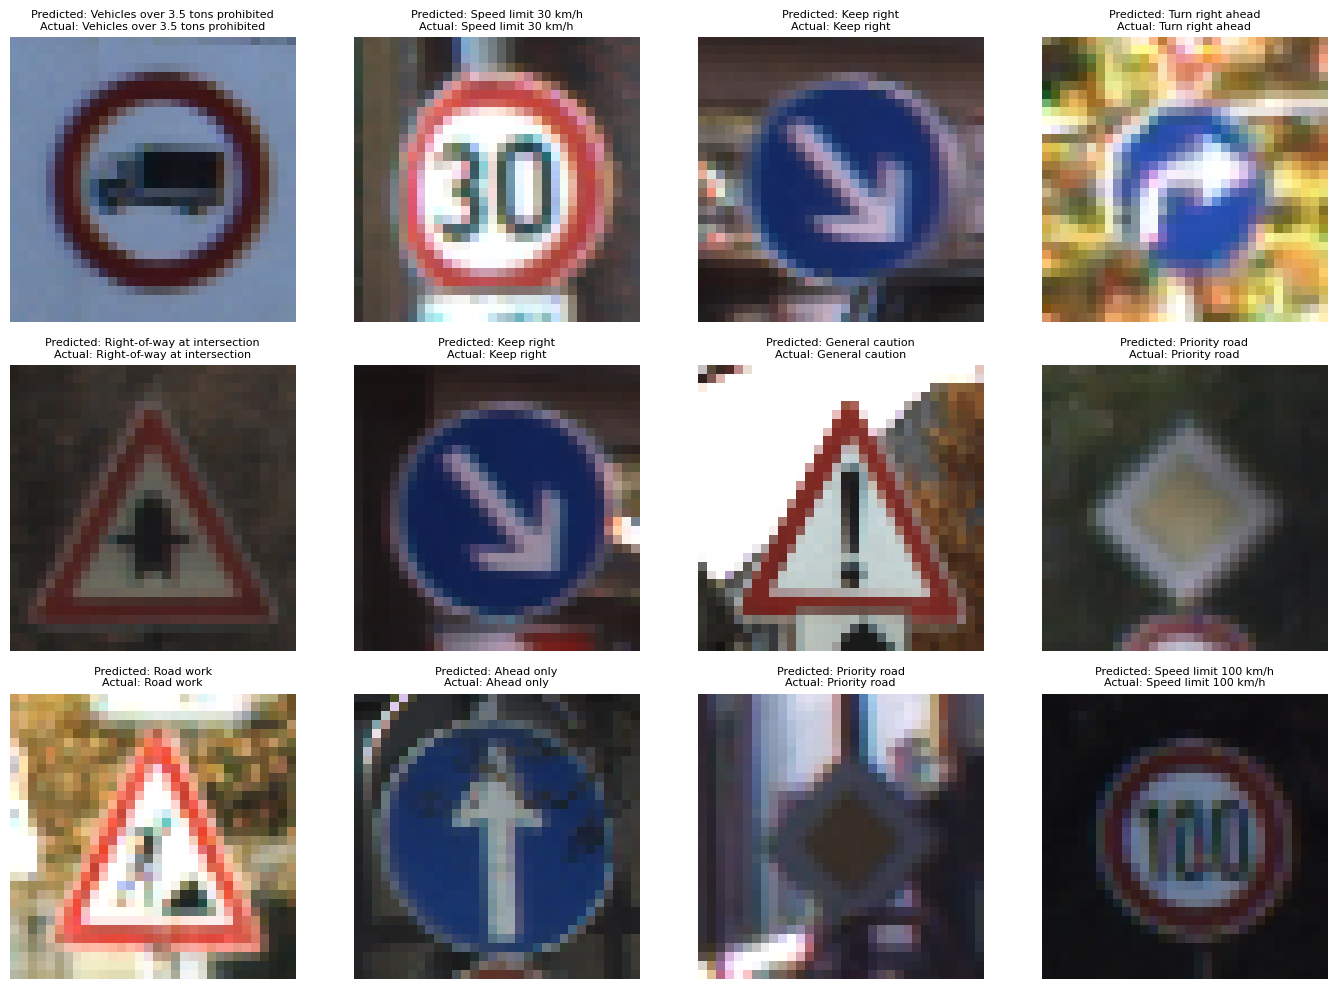

In [95]:
# Sample predictions on 12 test images

sample_predictions = traffic_model.predict(X_test[:12], verbose=0)
sample_predicted_classes = np.argmax(sample_predictions, axis=1)

plt.figure(figsize=(14, 10))

for i in range(12):

    predicted = sample_predicted_classes[i]
    actual = y_test[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i])

    plt.title(
        f"Predicted: {class_names[predicted]}\n"
        f"Actual: {class_names[actual]}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Display the incorrect predictions

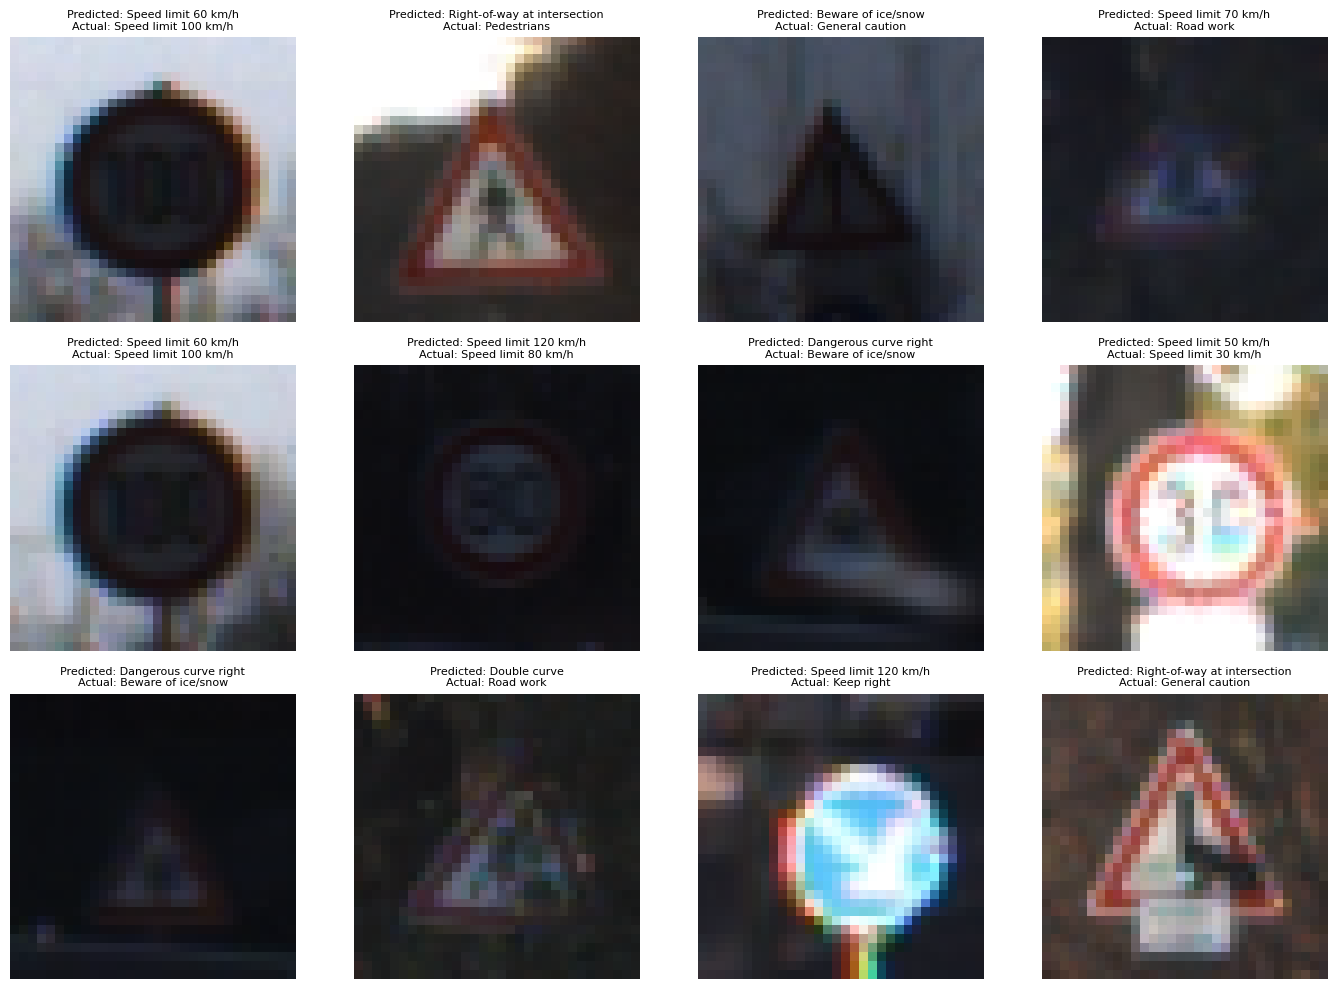

In [94]:
num_errors = min(12, len(incorrect_indices))

plt.figure(figsize=(14, 10))

for i in range(num_errors):

    index = incorrect_indices[i]

    actual = y_test[index]
    predicted = all_predicted_classes[index]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index])

    plt.title(
        f"Predicted: {class_names[predicted]}\n"
        f"Actual: {class_names[actual]}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Incorrect Classification Analysis

The trained CNN was evaluated on the official GTSRB test dataset and achieved a test accuracy of **93.47%**, with a test loss of **0.2705**.

The incorrectly classified traffic signs were identified by comparing the predicted class with the actual class. Sample misclassified images were displayed along with their predicted and actual traffic sign categories.

Misclassification can occur when different traffic signs have similar visual characteristics, when signs are partially obscured, or when lighting, image quality, viewing angle, or background conditions make the sign difficult to recognize.

The incorrect predictions provide useful information about the types of traffic signs that are more difficult for the CNN to distinguish.

## 27. Extension Activity – Traffic Sign Recognition

For the extension task, the CNN workflow can be applied to traffic sign images.

The proposed workflow is:

**Traffic Sign Images → Resize → Normalize → Train/Test Split → CNN → Training → Evaluation → Prediction Analysis**

The same CNN principles used for MNIST can be adapted to classify different traffic sign categories.

## 28. Concept Check

Answer the following questions before leaving the notebook:

1. What is a CNN?
2. Why is convolution useful for image data?
3. What is a kernel or filter?
4. What is a feature map?
5. What is the role of stride?
6. Why is padding used?
7. What is the purpose of ReLU?
8. Why is pooling used?
9. What does flattening do?
10. Why does the MNIST output layer contain 10 neurons?
11. What is the difference between training and testing data?
12. Why should model performance not be judged only from training accuracy?

## 28. Concept Check – Answers

### 1. What is a CNN?

A Convolutional Neural Network (CNN) is a deep learning model designed to process data with spatial structure, especially images. It learns useful features automatically through convolution and other layers.

### 2. Why is convolution useful for image data?

Convolution examines local regions of an image and detects useful patterns such as edges, textures, and shapes. The same filter can be applied across different image locations.

### 3. What is a kernel or filter?

A kernel or filter is a small matrix of learnable values that moves across an image and performs convolution to detect patterns.

### 4. What is a feature map?

A feature map is the output produced when a filter is applied across an input image. It represents how strongly the learned filter responds to different regions of the image.

### 5. What is the role of stride?

Stride determines how many pixels the filter moves at each step during convolution. A larger stride generally produces a smaller spatial output.

### 6. Why is padding used?

Padding adds extra pixels around the boundary of an image. It can help preserve spatial dimensions and allow boundary pixels to participate more fully in convolution.

### 7. What is the purpose of ReLU?

ReLU introduces non-linearity into the neural network by converting negative values to zero while keeping positive values unchanged.

### 8. Why is pooling used?

Pooling reduces the spatial dimensions of feature maps, which decreases computation and retains important feature responses.

### 9. What does flattening do?

Flattening converts multi-dimensional feature maps into a one-dimensional vector so that they can be passed to dense layers.

### 10. Why does the MNIST output layer contain 10 neurons?

MNIST contains ten digit classes, from 0 through 9. Therefore, the output layer contains ten neurons, one for each class.

### 11. What is the difference between training and testing data?

Training data is used to learn the model parameters. Testing data consists of previously unseen examples and is used to evaluate how well the trained model generalizes.

### 12. Why should model performance not be judged only from training accuracy?

Training accuracy only measures performance on data that the model has already seen. A model can have high training accuracy but perform poorly on unseen data due to overfitting. Validation and test performance provide additional information about generalization.

## 29. Key Takeaways

- A **CNN** is designed to learn useful patterns from image data.
- **Convolution** applies learnable filters to local image regions.
- **Feature maps** represent the response of filters to the input.
- **Stride** controls how far a filter moves.
- **Padding** controls how image boundaries are handled.
- **ReLU** introduces non-linearity.
- **Pooling** reduces spatial dimensions.
- **Flattening** converts feature maps into a vector.
- **Dense layers** use learned features for classification.
- **Softmax** produces class probabilities for multi-class classification.
- CNNs learn representations automatically through training.

**Final Slide Pointer: ➡️ Pixels → Features → Patterns → Representation → Prediction**

## Lab Submission Checklist

Before submitting the notebook, make sure that you have:

- [ ] Executed all required cells successfully.
- [ ] Completed all learner activities.
- [ ] Shown the MNIST sample images.
- [ ] Explained the convolution example.
- [ ] Calculated convolution output sizes.
- [ ] Built and trained the CNN.
- [ ] Reported test accuracy and loss.
- [ ] Displayed training and validation curves.
- [ ] Displayed sample predictions.
- [ ] Generated the confusion matrix.
- [ ] Analyzed at least one misclassification.
- [ ] Completed the hyperparameter experiment.
- [ ] Completed the code-completion activity.
- [ ] Attempted the wheat crop extension task.

### Suggested Student Deliverables

1. Completed `.ipynb` notebook.
2. Test accuracy and loss.
3. Training/validation graphs.
4. Confusion matrix.
5. Sample prediction visualization.
6. Short observation on model performance.
7. Hyperparameter experiment table.
8. Extension-task proposal or implementation, if assigned.